In [ ]:

from solvers import *
from ct import ct_astra
from projectors import *
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim
import matplotlib.ticker as mticker


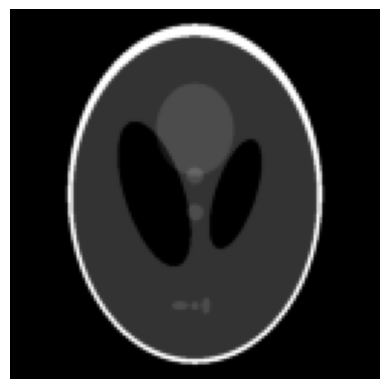

In [25]:
img_size = 128

base = shepp_logan_phantom()
X = resize(base, (img_size, img_size), order=1, mode='reflect', anti_aliasing=True).astype(np.float32)

plt.figure()
plt.imshow(X, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()

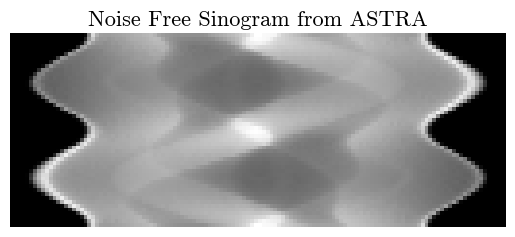

In [26]:
# CT setup
num_pixels      = np.shape(X)[0]    # Number of pixels in x/y direction (X needs to be square)
num_dets        = num_pixels        # Number of detector pixels
num_angles      = 50               # Number of projection angles
ang_start       = 0                 # Start angle in degress
ang_end         = 360               # End angle in degress
angles          = np.linspace(ang_start,ang_end,num_angles,dtype=int) / 180 * np.pi 
# %% ************************************ ASTRA ************************************
# Parameters for ASTRA
proj_model      = 'linear'          # The projection model: 'line', 'strip', or 'linear'
proj_geom       = 'parallel'         # The projection geometry: 'parallel' or 'fanflat'
source_origin   = 1000              # Distance from source to origin/center
origin_det      = 0                 # Distance from origin/center to detector
det_width       = 1                 # Detector width
gpu             = True              # Construct unmatched normal equations: 'False' or 'True' 
ct = ct_astra(num_pixels,num_angles,num_dets,angles,proj_model,proj_geom,source_origin,origin_det,det_width,gpu)

# Create Sinogram
_, Bexact = astra.create_sino(X, ct.proj_id)
plt.figure()
plt.imshow(Bexact, cmap='gray')
plt.title('Noise Free Sinogram from ASTRA',fontname='cmr10',fontsize=16)
plt.axis('off')
plt.show()

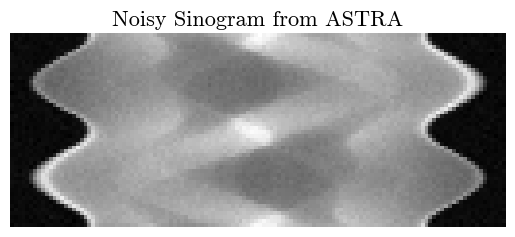

In [27]:
# Create noisy sinogram
rnl     = 0.025
e0      = np.random.normal(0.0, 1.0, ct.m)
e1      = e0/np.linalg.norm(e0)
bexact  = Bexact.reshape(-1)
e       = rnl*np.linalg.norm(bexact)*e1
b       = bexact + e
delta = np.std(e)

sino = b.reshape(num_angles,img_size)
plt.figure()
plt.imshow(sino, cmap='gray')
plt.title('Noisy Sinogram from ASTRA',fontname='cmr10',fontsize=16)
plt.axis('off')
plt.show()

In [28]:
A       = fp_astra(ct)     
B       = bp_astra(ct)     
p = 0
iter    = 100              # Maximum number of iterations
X_AB, R_AB = hybrid_AB_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 0, delta = delta)
X_AB_l, R_AB_l  = hybrid_AB_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 'lcurve', delta = delta)
X_AB_g, R_AB_g  = hybrid_AB_GMRES(A,B,b,iter, ct.m, ct.n, ct.num_angles, p = p, regparam = 'gcv', delta = delta)

X_BA, R_BA  = hybrid_BA_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 0, delta = delta)
X_BA_l, R_BA_l  = hybrid_BA_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 'lcurve', delta = delta)
X_BA_g, R_BA_g= hybrid_BA_GMRES(A,B,b,iter, ct.m, ct.n, ct.num_angles, p = p, regparam = 'gcv', delta = delta)




Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 2.2536 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 2.6342 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 6.0649 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 2.4515 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 2.8726 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 5.0533 seconds


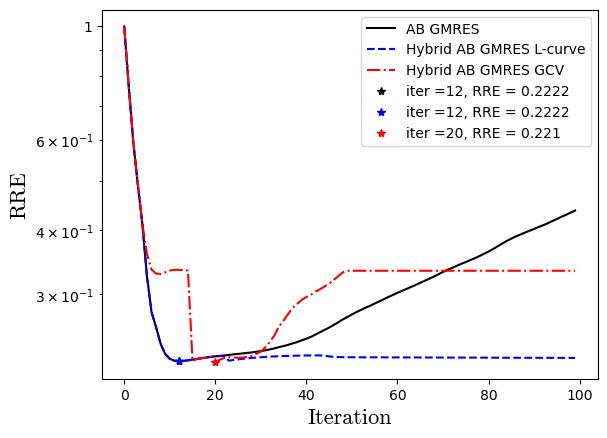

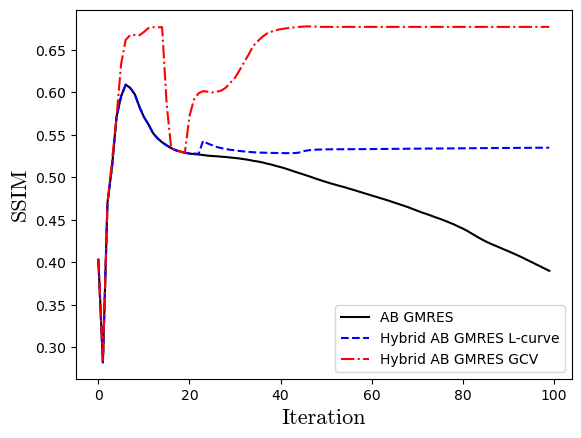

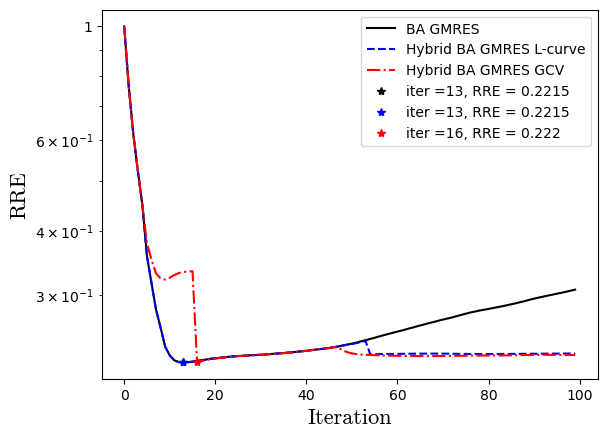

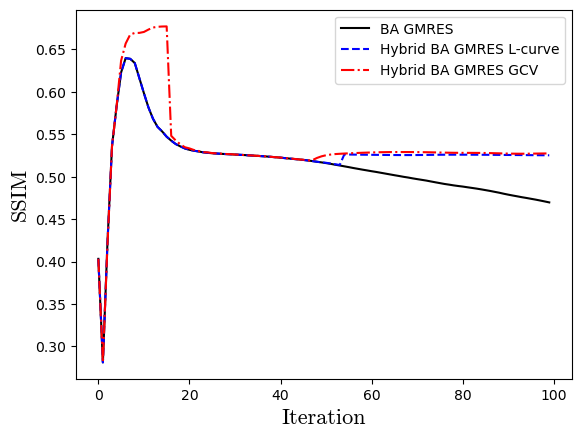

In [29]:
res_AB = np.zeros((iter,1))
res_AB_l = np.zeros((iter,1))
res_AB_g = np.zeros((iter,1))

ssim_AB = np.zeros((iter,1))
ssim_AB_l = np.zeros((iter,1))
ssim_AB_g = np.zeros((iter,1))


for i in range(0,iter):
    res_AB[i] = np.linalg.norm(X.reshape(-1) - X_AB[:,i])/np.linalg.norm(X.reshape(-1))
    res_AB_l[i] = np.linalg.norm(X.reshape(-1) - X_AB_l[:,i])/np.linalg.norm(X.reshape(-1))
    res_AB_g[i] = np.linalg.norm(X.reshape(-1) - X_AB_g[:,i])/np.linalg.norm(X.reshape(-1))

X = X.reshape(num_pixels, num_pixels)
for i in range(0,iter):
    ssim_AB[i] = ssim(X, X_AB[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_AB_l[i] = ssim(X, X_AB_l[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_AB_g[i] = ssim(X, X_AB_g[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())

val_AB = np.min(res_AB)
val_AB_l = np.min(res_AB_l)    
val_AB_g = np.min(res_AB_g)

idx_AB = np.argmin(res_AB)
idx_AB_l = np.argmin(res_AB_l)
idx_AB_g = np.argmin(res_AB_g)

# Plotting
plt.figure()
plt.semilogy(range(0,iter),res_AB,'k-')
plt.semilogy(range(0,iter),res_AB_l,'b--')
plt.semilogy(range(0,iter),res_AB_g,'r-.')
plt.semilogy(idx_AB,val_AB,'k*')
plt.semilogy(idx_AB_l,val_AB_l,'b*')
plt.semilogy(idx_AB_g,val_AB_g,'r*')
plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['AB GMRES', 'Hybrid AB GMRES L-curve', 'Hybrid AB GMRES GCV',
            'iter ='+str(idx_AB)+', RRE = '+str(round(val_AB,4)),
            'iter ='+str(idx_AB_l)+', RRE = '+str(round(val_AB_l,4)),
            'iter ='+str(idx_AB_g)+', RRE = '+str(round(val_AB_g,4))])
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))
plt.show()

plt.figure()
plt.plot(range(0,iter),ssim_AB,'k-')
plt.plot(range(0,iter),ssim_AB_l,'b--')
plt.plot(range(0,iter),ssim_AB_g,'r-.')
plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('SSIM',fontname='cmr10',fontsize=16)
plt.legend(['AB GMRES', 'Hybrid AB GMRES L-curve', 'Hybrid AB GMRES GCV'])
plt.show()
res_BA = np.zeros((iter,1))
res_BA_l = np.zeros((iter,1))
res_BA_g = np.zeros((iter,1))


for i in range(0,iter):
    res_BA[i] = np.linalg.norm(X.reshape(-1) - X_BA[:,i])/np.linalg.norm(X.reshape(-1))
    res_BA_l[i] = np.linalg.norm(X.reshape(-1) - X_BA_l[:,i])/np.linalg.norm(X.reshape(-1))
    res_BA_g[i] = np.linalg.norm(X.reshape(-1) - X_BA_g[:,i])/np.linalg.norm(X.reshape(-1))

ssim_BA = np.zeros((iter,1))
ssim_BA_l = np.zeros((iter,1))
ssim_BA_g = np.zeros((iter,1))
for i in range(0,iter):
    ssim_BA[i] = ssim(X, X_BA[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_BA_l[i] = ssim(X, X_BA_l[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_BA_g[i] = ssim(X, X_BA_g[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())


val_BA = np.min(res_BA)
val_BA_l = np.min(res_BA_l)
val_BA_g = np.min(res_BA_g)


idx_BA = np.argmin(res_BA)
idx_BA_l = np.argmin(res_BA_l)
idx_BA_g = np.argmin(res_BA_g)

# Plotting
plt.figure()
plt.gca().ticklabel_format(style='plain', axis='y')
plt.semilogy(range(0,iter),res_BA,'k-')
plt.semilogy(range(0,iter),res_BA_l,'b--')
plt.semilogy(range(0,iter),res_BA_g,'r-.')
plt.semilogy(idx_BA,val_BA,'k*')
plt.semilogy(idx_BA_l,val_BA_l,'b*')
plt.semilogy(idx_BA_g,val_BA_g,'r*')
plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['BA GMRES', 'Hybrid BA GMRES L-curve', 'Hybrid BA GMRES GCV',
            'iter ='+str(idx_BA)+', RRE = '+str(round(val_BA,4)),
            'iter ='+str(idx_BA_l)+', RRE = '+str(round(val_BA_l,4)),
            'iter ='+str(idx_BA_g)+', RRE = '+str(round(val_BA_g,4))])
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))
plt.show()

plt.figure()
plt.plot(range(0,iter),ssim_BA,'k-')
plt.plot(range(0,iter),ssim_BA_l,'b--')
plt.plot(range(0,iter),ssim_BA_g,'r-.')
plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('SSIM',fontname='cmr10',fontsize=16)
plt.legend(['BA GMRES', 'Hybrid BA GMRES L-curve', 'Hybrid BA GMRES GCV'])
plt.show()

In [30]:
regparam = 'lcurve'

X_AB, R_AB = hybrid_AB_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = 0, regparam= regparam, delta = delta)
X_AB3, R_AB3 = hybrid_AB_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = 3, regparam= regparam, delta = delta)
X_AB5, R_AB5 = hybrid_AB_GMRES(A,B,b,iter, ct.m, ct.n, ct.num_angles, p = 5, regparam = regparam, delta = delta)
X_AB10, R_AB10 = hybrid_AB_GMRES(A,B,b,iter, ct.m, ct.n, ct.num_angles, p = 10, regparam = regparam, delta = delta)



Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 2.6508 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 2.3402 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 2.3276 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 2.2096 seconds


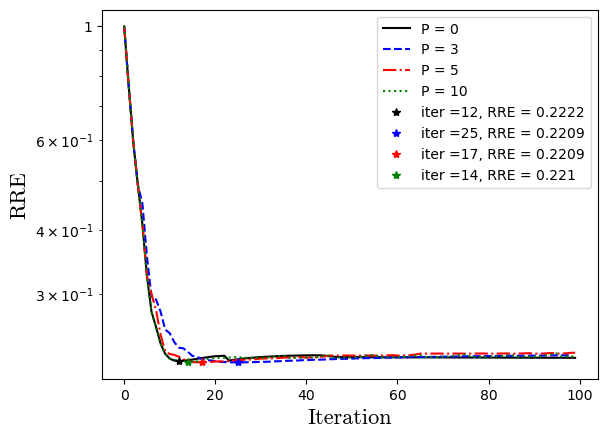

In [31]:
res_AB = np.zeros((iter,1))
res_AB3 = np.zeros((iter - iter%3,1))
res_AB5 = np.zeros((iter,1))
res_AB10 = np.zeros((iter,1))


for i in range(0,iter-iter%3):
    res_AB3[i] = np.linalg.norm(X.reshape(-1) - X_AB3[:,i])/np.linalg.norm(X.reshape(-1))

for i in range(0,iter):
    res_AB[i] = np.linalg.norm(X.reshape(-1) - X_AB[:,i])/np.linalg.norm(X.reshape(-1))
    res_AB5[i] = np.linalg.norm(X.reshape(-1) - X_AB5[:,i])/np.linalg.norm(X.reshape(-1))
    res_AB10[i] = np.linalg.norm(X.reshape(-1) - X_AB10[:,i])/np.linalg.norm(X.reshape(-1))

val_AB = np.min(res_AB)
val_AB3 = np.min(res_AB3)
val_AB5 = np.min(res_AB5)
val_AB10 = np.min(res_AB10)

idx_AB = np.argmin(res_AB)
idx_AB3 = np.argmin(res_AB3)
idx_AB5 = np.argmin(res_AB5)
idx_AB10 = np.argmin(res_AB10)


# Plotting
plt.figure()
plt.gca().ticklabel_format(style='plain', axis='y')
plt.semilogy(range(0,iter),res_AB,'k-')
plt.semilogy(range(0,iter-iter%3),res_AB3,'b--')
plt.semilogy(range(0,iter),res_AB5,'r-.')
plt.semilogy(range(0,iter),res_AB10,'g:')
plt.semilogy(idx_AB,val_AB,'k*')
plt.semilogy(idx_AB3,val_AB3,'b*')
plt.semilogy(idx_AB5,val_AB5,'r*')
plt.semilogy(idx_AB10,val_AB10,'g*')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))

plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['P = 0', 'P = 3', 'P = 5', 'P = 10',
            'iter ='+str(idx_AB)+', RRE = '+str(round(val_AB,4)),
            'iter ='+str(idx_AB3)+', RRE = '+str(round(val_AB3,4)),
            'iter ='+str(idx_AB5)+', RRE = '+str(round(val_AB5,4)),
            'iter ='+str(idx_AB10)+', RRE = '+str(round(val_AB10,4))])
plt.show()